In [1]:
import torch
import math
from pyDOE import lhs   # or scipy.stats.qmc.LatinHypercube
import torch.nn as nn
import torch.optim as optim
import numpy as np
import time
import matplotlib.pyplot as plt
from tqdm import trange
import gc
import logging
from torch.func import jacrev, vmap, hessian, jacfwd
from torch.utils.data import TensorDataset, DataLoader
import random
import scipy.io
import torch.nn.init as init
logging.getLogger("torch").setLevel(logging.ERROR)
np.random.seed(1234)
torch.manual_seed(1234)
device = torch.device('cuda:2')

In [2]:
class DeepMLP(nn.Module):
    def __init__(self, layer_sizes, activation):
        super().__init__()
        self.activation = activation
        weights, biases, scalers = [], [], []
        
        
        for idx in range(1, len(layer_sizes)-1):
            in_dim, out_dim = layer_sizes[idx - 1], layer_sizes[idx]
            if idx == 1:
                weights.append(nn.Parameter(torch.randn(in_dim, out_dim)))
                scalers.append(nn.Parameter(torch.randn(1, out_dim) * 10.0))
                biases.append(nn.Parameter(torch.empty(in_dim, out_dim).uniform_(-1.0, 1.0)))

            else:
                weights.append(nn.Parameter(torch.randn(in_dim, out_dim)))
                biases.append(nn.Parameter(torch.zeros(1, out_dim)))
                

        std = (1.0 / layer_sizes[-2]) ** 0.5
        w = nn.Parameter(torch.randn(layer_sizes[-2], layer_sizes[-1]) * std)
        weights.append(w)
        biases.append(nn.Parameter(torch.zeros(1, layer_sizes[-1])))      
                

        self.W = nn.ParameterList(weights)
        self.W_a = nn.ParameterList(scalers)
        self.b = nn.ParameterList(biases)
        
    
    def forward(self, x, x_min, x_max):

        features = []
        A = 2.0 * (x - x_min) / (x_max - x_min) - 1.0
        
        for i in range(len(self.W) - 1):
            if i == 0:
                W_temp = self.W_a[i]
                A = self.activation(A @ W_temp - W_temp * self.b[i])
            else:
                A = self.activation(A @ self.W[i] + self.b[i])
        features.append(A)

        y = A @ self.W[-1] + self.b[-1]
        
        return y , features

In [3]:
class Separable4DNet(nn.Module):
    def __init__(self, layer_sizes, activation=torch.tanh):
        super().__init__()
        self.branch_x = DeepMLP(layer_sizes, activation=activation)
        self.branch_y = DeepMLP(layer_sizes, activation=activation)
        self.branch_z = DeepMLP(layer_sizes, activation=activation)
        self.branch_t = DeepMLP(layer_sizes, activation=activation)
        
        self.final_linear = nn.Linear(layer_sizes[-1], 1)
        
        std = (1.0/ layer_sizes[-1]) ** 0.5 
        init.normal_(self.final_linear.weight, mean=0.0, std=std)
        init.zeros_(self.final_linear.bias)
        
        # defaults assume inputs in [0, 1]; override via set_bounds
        mins = torch.zeros(4, 1)
        maxs = torch.ones(4, 1)
        self.register_buffer("mins", mins)
        self.register_buffer("maxs", maxs)

    def set_bounds(self, mins, maxs):
        """mins/maxs are 4×1 tensors with per-axis min/max."""
        self.mins.copy_(mins)
        self.maxs.copy_(maxs)

    def forward(self, X_star):
        x = X_star[:, 0:1]
        y = X_star[:, 1:2]
        z = X_star[:, 2:3]
        t = X_star[:, 3:4]

        yx, feat_x = self.branch_x(x, self.mins[0:1], self.maxs[0:1])

        yy, feat_y = self.branch_y(y, self.mins[1:2], self.maxs[1:2])
        yz, feat_z = self.branch_z(z, self.mins[2:3], self.maxs[2:3])
        yt, feat_t = self.branch_t(t, self.mins[3:4], self.maxs[3:4])

        outer_product = yx * yy * yz * yt
        y_pred = self.final_linear(outer_product)
        return y_pred, (feat_x, feat_y, feat_z, feat_t)


In [4]:
def y_target(x, y, z, t):
    aaaaaa = 100
    return (
        torch.sin(90   * math.pi * x**2) * torch.exp(-x**2)
        + torch.sin(100 * math.pi * y**2) * torch.exp(-y**2)
        + torch.sin(110 * math.pi * z**2) * torch.exp(-z**2)
        + torch.sin(120 * math.pi * t**2) * torch.exp(-t**2))

axis = torch.linspace(-1.0, 1.0, 20).unsqueeze(1)
X, Y, Z, T = torch.meshgrid(axis.squeeze(), axis.squeeze(), axis.squeeze(), axis.squeeze(), indexing="ij")
X_star = torch.stack([X.reshape(-1), Y.reshape(-1), Z.reshape(-1), T.reshape(-1)], dim=1)

targets = y_target(X_star[:, 0:1], X_star[:, 1:2], X_star[:, 2:3], X_star[:, 3:4])

In [5]:
layers = [1] + [300] * 5
model = Separable4DNet(layers).to(device)

# once per dataset
mins = torch.tensor([[-1.0], [-1.0], [-1.0], [-1.0]], device=device)
maxs = torch.tensor([[1.0], [1.0], [1.0], [1.0]], device=device)
model.set_bounds(mins, maxs)

# def init_output_scale(branch):
#     axis = torch.linspace(-1.0, 1.0, 100, dtype=torch.float32, device=device).unsqueeze(1)
#     x_min = axis.min(dim=0, keepdim=True).values
#     x_max = axis.max(dim=0, keepdim=True).values

#     with torch.no_grad():
#         y_pref = branch.preforward(axis, x_min, x_max)
#         scale = torch.max(torch.abs(y_pref), dim=0, keepdim=True).values
#         print(scale)
#         branch.output_scale.copy_(scale)

# for branch in (model.branch_x, model.branch_y, model.branch_z,model.branch_t):
#     init_output_scale(branch)

In [6]:
with torch.no_grad():
    y_pred, _ = model(X_star.to(device))

y_test = y_pred.view(-1, 1)
y_ref = targets.view(-1, 1).to(device)

err = torch.linalg.norm(y_test - y_ref) / torch.linalg.norm(y_ref)
print(f"Error(L2): {err:.5e}")

cube_ref = y_ref.view(len(axis), len(axis), len(axis),len(axis)).cpu().numpy()
cube_test = y_test.view(len(axis), len(axis), len(axis),len(axis)).cpu().numpy()

Error(L2): 1.18752e+00


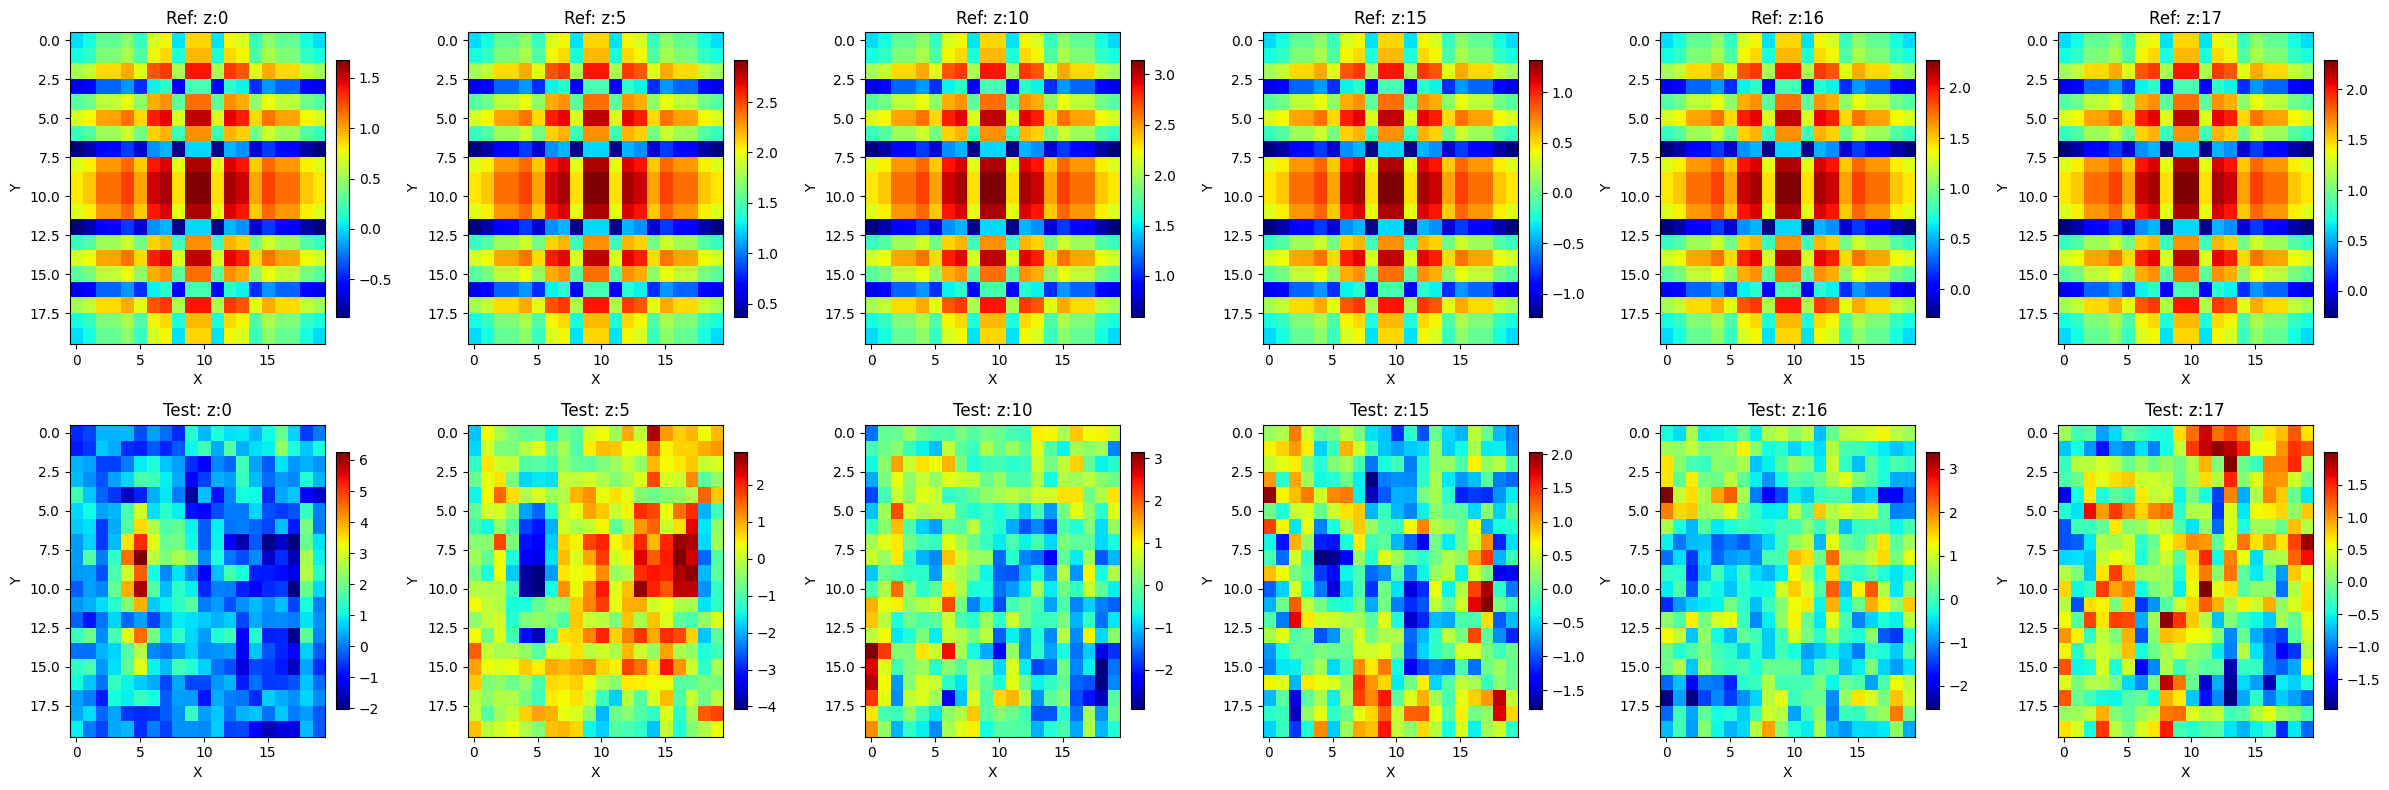

In [7]:
import matplotlib.pyplot as plt

slice_indices = [0, 5, 10, 15, 16, 17]
fig, axes = plt.subplots(2, len(slice_indices), figsize=(4 * len(slice_indices), 8))

for i, idx in enumerate(slice_indices):
    im1 = axes[0, i].imshow(cube_ref[idx,idx], cmap="jet", aspect="auto")
    axes[0, i].set_title(f"Ref: z:{idx}")
    axes[0, i].set_xlabel("X")
    axes[0, i].set_ylabel("Y")

    im2 = axes[1, i].imshow(cube_test[idx,idx], cmap="jet", aspect="auto")
    axes[1, i].set_title(f"Test: z:{idx}")
    axes[1, i].set_xlabel("X")
    axes[1, i].set_ylabel("Y")

    plt.colorbar(im1, ax=axes[0, i], fraction=0.046, pad=0.04)
    plt.colorbar(im2, ax=axes[1, i], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [8]:
criterion = nn.MSELoss()
initial_lr = 1.0e-3
alpha = 1e-7 / 1e-3

optimizer = torch.optim.Adam(model.parameters(), lr=initial_lr)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50000, eta_min=initial_lr * alpha)

In [9]:
loss_history = []

nmax = 50000
N_f  = 4096

start_start_time = time.time()
start_start_time_record = time.time()
for n in range(1, nmax + 1):

    lhs_samples = lhs(4, N_f)*2-1
    X_f = torch.tensor(lhs_samples, dtype=torch.float32, device=device)
    y_batch = y_target(X_f[:, 0:1], X_f[:, 1:2], X_f[:, 2:3], X_f[:, 3:4])

    optimizer.zero_grad()
    y_pred, _ = model(X_f)
    loss = criterion(y_pred, y_batch)
    loss.backward()
    optimizer.step()
    scheduler.step()

    if n % 1000 == 0:
        bx_mean = model.branch_x.b[0].mean().item()
        by_mean = model.branch_y.b[0].mean().item()
        print(f"n: {n}, loss: {loss.item():.3e}, b_x_mean: {bx_mean:.3e}, b_y_mean: {by_mean:.3e},time: {int(time.time() - start_start_time)}")
        loss_history.append(loss.item())
#         print(f"KK: {loss.item():.10f}")
        start_start_time = time.time()

n: 1000, loss: 2.557e-02, b_x_mean: -3.658e-02, b_y_mean: -2.892e-02,time: 11
n: 2000, loss: 1.698e-02, b_x_mean: -3.650e-02, b_y_mean: -2.910e-02,time: 11
n: 3000, loss: 2.080e-02, b_x_mean: -3.675e-02, b_y_mean: -2.923e-02,time: 11
n: 4000, loss: 1.649e-02, b_x_mean: -3.663e-02, b_y_mean: -2.917e-02,time: 11
n: 5000, loss: 1.316e-02, b_x_mean: -3.654e-02, b_y_mean: -2.931e-02,time: 11
n: 6000, loss: 1.443e-02, b_x_mean: -3.655e-02, b_y_mean: -2.944e-02,time: 11
n: 7000, loss: 9.018e-03, b_x_mean: -3.656e-02, b_y_mean: -2.968e-02,time: 11
n: 8000, loss: 1.174e-02, b_x_mean: -3.661e-02, b_y_mean: -2.977e-02,time: 11
n: 9000, loss: 8.624e-03, b_x_mean: -3.661e-02, b_y_mean: -2.986e-02,time: 11
n: 10000, loss: 9.055e-03, b_x_mean: -3.656e-02, b_y_mean: -2.962e-02,time: 11
n: 11000, loss: 7.546e-03, b_x_mean: -3.672e-02, b_y_mean: -2.977e-02,time: 10
n: 12000, loss: 6.517e-03, b_x_mean: -3.672e-02, b_y_mean: -2.996e-02,time: 10
n: 13000, loss: 7.282e-03, b_x_mean: -3.661e-02, b_y_mean: -2

In [10]:
start_start_time_record - time.time()

-551.3528935909271

In [11]:
loss

tensor(1.6460e-05, device='cuda:2', grad_fn=<MseLossBackward0>)

In [12]:
with torch.no_grad():
    y_pred, _ = model(X_star.to(device))

y_test = y_pred.view(-1, 1)
y_ref = targets.view(-1, 1).to(device)

err = torch.linalg.norm(y_test - y_ref) / torch.linalg.norm(y_ref)
print(f"Error(L2): {err:.5e}")

cube_ref = y_ref.view(len(axis), len(axis), len(axis),len(axis)).cpu().numpy()
cube_test = y_test.view(len(axis), len(axis), len(axis),len(axis)).cpu().numpy()

Error(L2): 5.96844e-03


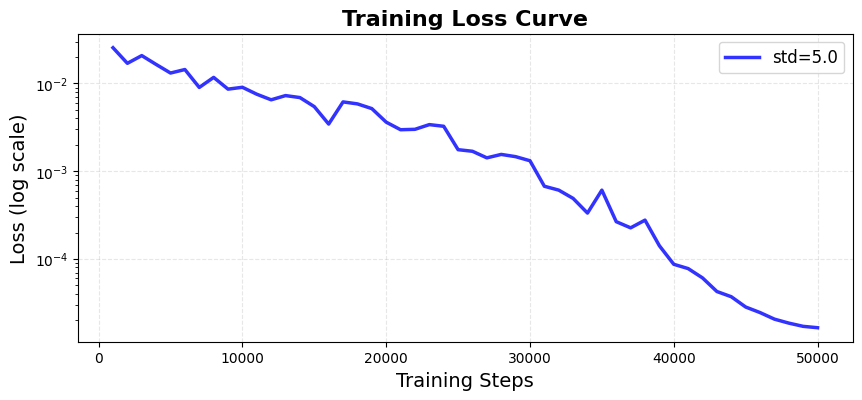

In [13]:
steps = [(i + 1) * 1000 for i in range(len(loss_history))]

plt.figure(figsize=(10, 4))
plt.plot(steps, loss_history, "b-", linewidth=2.5, alpha=0.8, label="std=5.0")

if max(loss_history) / min(loss_history) > 100:
    plt.yscale("log")
    ylabel = "Loss (log scale)"
else:
    ylabel = "Loss"

plt.xlabel("Training Steps", fontsize=14)
plt.ylabel(ylabel, fontsize=14)
plt.title("Training Loss Curve", fontsize=16, fontweight="bold")
plt.grid(True, alpha=0.3, linestyle="--")
plt.legend(fontsize=12)
plt.show()


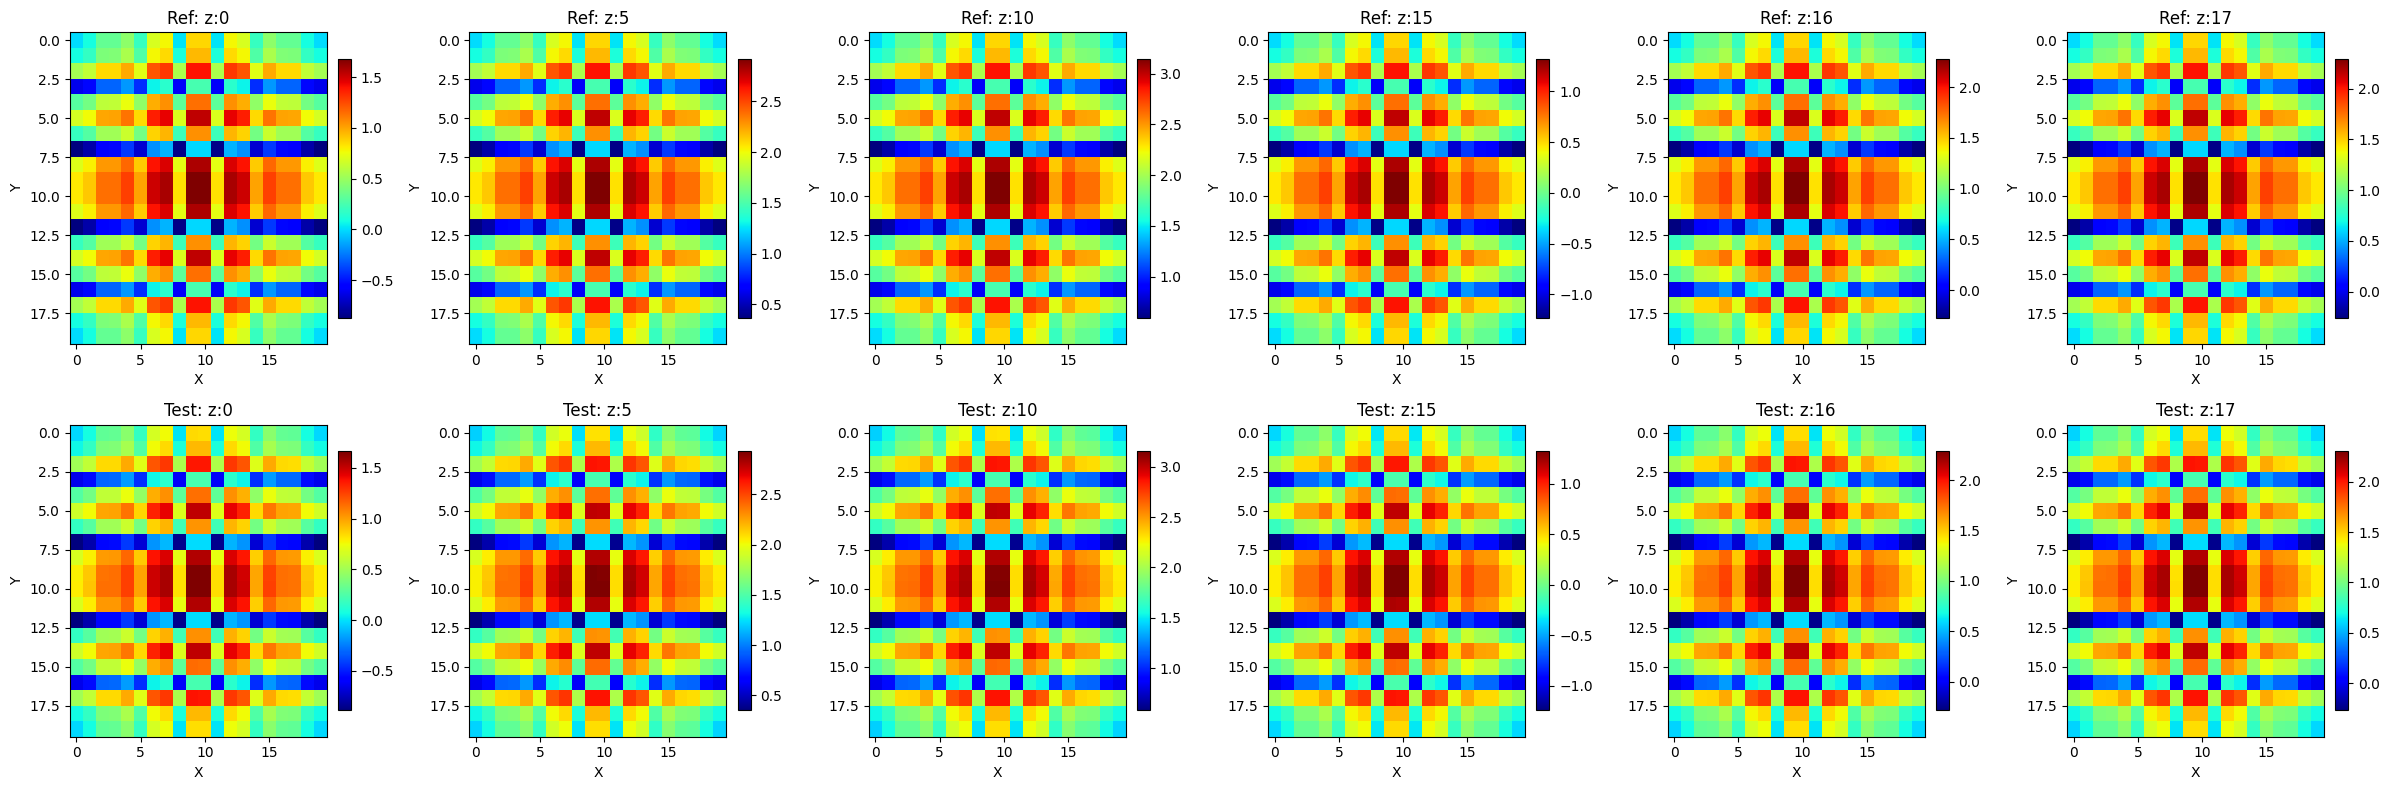

In [14]:
import matplotlib.pyplot as plt

slice_indices = [0, 5, 10, 15, 16, 17]
fig, axes = plt.subplots(2, len(slice_indices), figsize=(4 * len(slice_indices), 8))

for i, idx in enumerate(slice_indices):
    im1 = axes[0, i].imshow(cube_ref[idx,idx], cmap="jet", aspect="auto")
    axes[0, i].set_title(f"Ref: z:{idx}")
    axes[0, i].set_xlabel("X")
    axes[0, i].set_ylabel("Y")

    im2 = axes[1, i].imshow(cube_test[idx,idx], cmap="jet", aspect="auto")
    axes[1, i].set_title(f"Test: z:{idx}")
    axes[1, i].set_xlabel("X")
    axes[1, i].set_ylabel("Y")

    plt.colorbar(im1, ax=axes[0, i], fraction=0.046, pad=0.04)
    plt.colorbar(im2, ax=axes[1, i], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [15]:
X_star = lhs(4, 100000)*2-1
X_star = torch.tensor(X_star, dtype=torch.float32, device=device)
targets = y_target(X_star[:, 0:1], X_star[:, 1:2], X_star[:, 2:3], X_star[:, 3:4])

with torch.no_grad():
    y_pred, _ = model(X_star.to(device))

y_test = y_pred.view(-1, 1)
y_ref = targets.view(-1, 1).to(device)

err = torch.linalg.norm(y_test - y_ref) / torch.linalg.norm(y_ref)
print(f"Error(L2): {err:.5e}")

Error(L2): 3.75610e-03


In [16]:
axis = torch.linspace(-1.0, 1.0, 1000).unsqueeze(1)
X, Y = torch.meshgrid(axis.squeeze(), axis.squeeze(), indexing="ij")
X_star = torch.stack([X.reshape(-1), Y.reshape(-1)], dim=1)
zeros = torch.zeros((X_star.shape[0], 2))
X_star = torch.hstack([X_star, zeros])

targets = y_target(X_star[:, 0:1], X_star[:, 1:2], X_star[:, 2:3], X_star[:, 3:4])

with torch.no_grad():
    y_pred, _ = model(X_star.to(device))

y_test = y_pred.view(-1, 1).cpu().numpy()
y_ref = targets.view(-1, 1).to(device).cpu().numpy()

scipy.io.savemat("4dy_pre.mat", {'u': y_test}) 
scipy.io.savemat("4dy_ref.mat", {'u': y_ref}) 

In [17]:
y_test = y_pred.view(-1, 1)
y_ref = targets.view(-1, 1).to(device)

err = torch.linalg.norm(y_test - y_ref) / torch.linalg.norm(y_ref)
print(f"Error(L2): {err:.5e}")

Error(L2): 2.96748e-03


In [18]:
loss = criterion(y_test, y_ref)

In [19]:
axis = torch.linspace(-1.0, 1.0, 10000).unsqueeze(1)
X_star = axis
zeros = torch.zeros((X_star.shape[0], 3))
X_star = torch.hstack([X_star, zeros])

targets = y_target(X_star[:, 0:1], X_star[:, 1:2], X_star[:, 2:3], X_star[:, 3:4])

with torch.no_grad():
    y_pred, _ = model(X_star.to(device))

y_test = y_pred.view(-1, 1).cpu().numpy()
y_ref = targets.view(-1, 1).to(device).cpu().numpy()

scipy.io.savemat("4dy_pre2.mat", {'u': y_test}) 
scipy.io.savemat("4dy_ref2.mat", {'u': y_ref}) 